In [4]:
# load multi-task cell GNN slide predictions

import joblib

slide_pred = joblib.load('/data2/r10user3/Spatial_Gene_Cell_Ratio/code/predictions/cell_gene_2layersimpleGNN_lr1e-4_best_cell_all_abundance_average.pkl')

In [2]:
slide_pred.keys()

dict_keys(['WSA_LngSP8759311', 'WSA_LngSP8759312', 'WSA_LngSP8759313'])

In [3]:
slide_pred['WSA_LngSP8759312'].keys()

dict_keys(['cell_abundance_predictions', 'cell_abundance_labels', 'spot_names'])

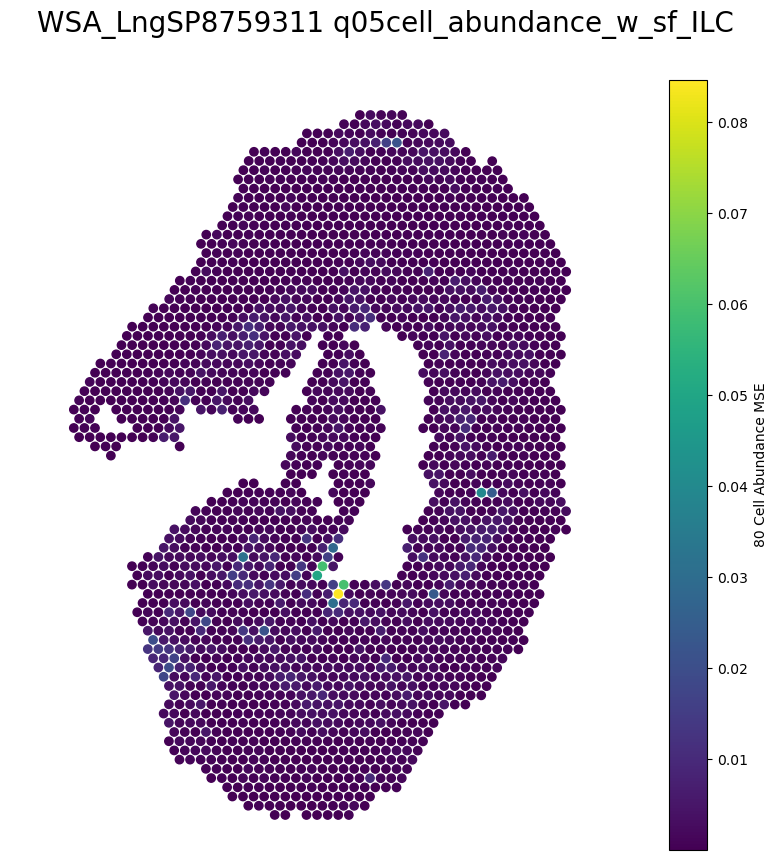

In [62]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
import numpy as np

slide = "WSA_LngSP8759311"
spots_coord = pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'spots.csv'), index_col=0)
cell_names = list(pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'cell_ratio.csv')).columns)[1:]

i = 38

preds = slide_pred[slide]['cell_abundance_predictions']
labels = slide_pred[slide]['cell_abundance_labels']
# Calculate the MSE between preds and labels per sample
mse_per_sample = np.mean((labels[:, i:i+1] - preds[:, i:i+1])**2, axis=1)
# mse_per_sample = np.mean((labels - preds)**2, axis=1)
# Reshape the resulting 1D array into a 2D array of shape (1000, 1)
mse_per_sample = mse_per_sample.reshape((-1, 1))

patch_names = slide_pred[slide]['spot_names']
preds_df = pd.DataFrame(data=mse_per_sample, index=patch_names, columns=["preds"])
merged_df = pd.merge(spots_coord, preds_df, left_index=True, right_index=True, how='inner')
X = merged_df['X']
Y = merged_df['Y']
A = merged_df['preds']

# set figure size
figsize(10, 10)

# Create a scatter plot with a color map
plt.scatter(X, Y, c=A, cmap='viridis')

# Add a color bar with the spot values
cbar = plt.colorbar()
cbar.set_label('80 Cell Abundance MSE')

# Add title
plt.suptitle(slide + ' ' + cell_names[i], fontsize=20, y=0.95)
# Flip y-axis
plt.gca().invert_yaxis()

# Show the plot
plt.axis('equal')
plt.axis('off')
plt.show()

In [5]:
# visualize multi-task cell GNN slide predictions

from matplotlib import cm
import os
import cv2
import pandas as pd
from tqdm import tqdm

viridis = cm.get_cmap('viridis', 1000)

for slide in slide_pred:
    slide_name = slide
    preds = slide_pred[slide]['cell_abundance_predictions']
    patch_names = slide_pred[slide]['spot_names']

    # Normalize the ndarray by column
    preds = preds / preds.max(axis=0)

    # Standardize the ndarray by column
    mean = preds.mean(axis=0)
    std = preds.std(axis=0)
    preds = (preds - mean) / std
    
    # assign spot color
    all_gene_patch_RGB = list()
    for i in range(80):
        gene_pred = preds[:,i]
        patch_RGB = dict()
        for j in range(gene_pred.size):
            rgba = viridis(gene_pred[j])
            patch_RGB[patch_names[j].split('.')[0]] = (
                int(rgba[2]*255),
                int(rgba[1]*255),
                int(rgba[0]*255))
        all_gene_patch_RGB.append(patch_RGB)
        
    # visualize for each class
    patch_size = 112
    spots_coord = pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'spots.csv'))
    cell_names = list(pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'cell_ratio.csv')).columns)[1:]
    for i in tqdm(range(80)):
        img_path = os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, slide+'.jpg')
        im = cv2.imread(img_path)
        for index, row in spots_coord.iterrows():
            spot_id = row['spot_id']
            X = row['X']
            Y = row['Y']
            try:
                rgb = all_gene_patch_RGB[i][spot_id]
                cv2.circle(im, (X, Y), patch_size, rgb, thickness=-1)
            except:
                continue
        
        write_dir = os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, "cell_abundance_figure")
        if not os.path.exists(write_dir):
            os.makedirs(write_dir)
            
        write_path = os.path.join(write_dir, cell_names[i]+'_multi_task.jpg')
        cv2.imwrite(write_path, im)

100%|██████████| 80/80 [08:42<00:00,  6.53s/it]


In [6]:
# visualize cell ground truth

for slide in slide_pred:
    slide_name = slide
    preds = slide_pred[slide]['cell_abundance_labels']
    patch_names = slide_pred[slide]['spot_names']

    # Normalize the ndarray by column
    preds = preds / preds.max(axis=0)

    # Standardize the ndarray by column
    mean = preds.mean(axis=0)
    std = preds.std(axis=0)
    preds = (preds - mean) / std
    
    # assign spot color
    all_gene_patch_RGB = list()
    for i in range(80):
        gene_pred = preds[:,i]
        patch_RGB = dict()
        for j in range(gene_pred.size):
            rgba = viridis(gene_pred[j])
            patch_RGB[patch_names[j].split('.')[0]] = (
                int(rgba[2]*255),
                int(rgba[1]*255),
                int(rgba[0]*255))
        all_gene_patch_RGB.append(patch_RGB)
        
    # visualize for each class
    patch_size = 112
    spots_coord = pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'spots.csv'))
    cell_names = list(pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'cell_ratio.csv')).columns)[1:]
    for i in tqdm(range(80)):
        img_path = os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, slide+'.jpg')
        im = cv2.imread(img_path)
        for index, row in spots_coord.iterrows():
            spot_id = row['spot_id']
            X = row['X']
            Y = row['Y']
            try:
                rgb = all_gene_patch_RGB[i][spot_id]
                cv2.circle(im, (X, Y), patch_size, rgb, thickness=-1)
            except:
                continue
        
        write_dir = os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, "cell_abundance_figure")
        if not os.path.exists(write_dir):
            os.makedirs(write_dir)
            
        write_path = os.path.join(write_dir, cell_names[i]+'_ground_truth.jpg')
        cv2.imwrite(write_path, im)

100%|██████████| 80/80 [08:42<00:00,  6.54s/it]


In [7]:
# load single-task cell GNN slide predictions

import joblib

slide_pred = joblib.load('/data2/r10user3/Spatial_Gene_Cell_Ratio/code/predictions/only_cell_2layersimpleGNN_lr1e-4_best_cell_all_abundance_average.pkl')

In [9]:
# visualize single-task cell GNN slide predictions

from matplotlib import cm
import os
import cv2
import pandas as pd
from tqdm import tqdm

viridis = cm.get_cmap('viridis', 1000)

for slide in slide_pred:
    slide_name = slide
    preds = slide_pred[slide]['cell_abundance_predictions']
    patch_names = slide_pred[slide]['spot_names']

    # Normalize the ndarray by column
    preds = preds / preds.max(axis=0)

    # Standardize the ndarray by column
    mean = preds.mean(axis=0)
    std = preds.std(axis=0)
    preds = (preds - mean) / std
    
    # assign spot color
    all_gene_patch_RGB = list()
    for i in range(80):
        gene_pred = preds[:,i]
        patch_RGB = dict()
        for j in range(gene_pred.size):
            rgba = viridis(gene_pred[j])
            patch_RGB[patch_names[j].split('.')[0]] = (
                int(rgba[2]*255),
                int(rgba[1]*255),
                int(rgba[0]*255))
        all_gene_patch_RGB.append(patch_RGB)
        
    # visualize for each class
    patch_size = 112
    spots_coord = pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'spots.csv'))
    cell_names = list(pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'cell_ratio.csv')).columns)[1:]
    for i in tqdm(range(80)):
        img_path = os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, slide+'.jpg')
        im = cv2.imread(img_path)
        for index, row in spots_coord.iterrows():
            spot_id = row['spot_id']
            X = row['X']
            Y = row['Y']
            try:
                rgb = all_gene_patch_RGB[i][spot_id]
                cv2.circle(im, (X, Y), patch_size, rgb, thickness=-1)
            except:
                continue
        
        write_dir = os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, "cell_abundance_figure")
        if not os.path.exists(write_dir):
            os.makedirs(write_dir)
            
        write_path = os.path.join(write_dir, cell_names[i]+'_single_task.jpg')
        cv2.imwrite(write_path, im)

100%|██████████| 80/80 [08:41<00:00,  6.52s/it]


In [1]:
# load multi-task gene GNN slide predictions

import joblib

slide_pred = joblib.load('//data2/r10user3/Spatial_Gene_Cell_Ratio/code/predictions/cell_gene_2layersimpleGNN_lr1e-4_best_gene_all_average.pkl')

In [2]:
slide_pred.keys()

dict_keys(['WSA_LngSP8759311', 'WSA_LngSP8759312', 'WSA_LngSP8759313'])

In [3]:
slide_pred['WSA_LngSP8759311'].keys()

dict_keys(['gene_predictions', 'gene_labels', 'spot_names'])

In [9]:
# visualize multi-task gene GNN slide predictions

from matplotlib import cm
import os
import cv2
import pandas as pd
from tqdm import tqdm

viridis = cm.get_cmap('viridis', 1000)

for slide in slide_pred:
    slide_name = slide
    preds = slide_pred[slide]['gene_predictions']
    patch_names = slide_pred[slide]['spot_names']

    # Normalize the ndarray by column
    preds = preds / preds.max(axis=0)

    # Standardize the ndarray by column
    mean = preds.mean(axis=0)
    std = preds.std(axis=0)
    preds = (preds - mean) / std
    
    # assign spot color
    all_gene_patch_RGB = list()
    for i in range(250):
        gene_pred = preds[:,i]
        patch_RGB = dict()
        for j in range(gene_pred.size):
            rgba = viridis(gene_pred[j])
            patch_RGB[patch_names[j].split('.')[0]] = (
                int(rgba[2]*255),
                int(rgba[1]*255),
                int(rgba[0]*255))
        all_gene_patch_RGB.append(patch_RGB)
        
    # visualize for each class
    patch_size = 112
    spots_coord = pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'spots.csv'))
    gene_names = list(pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'high_250_stdata.csv')).columns)[1:]
    for i in tqdm(range(250)):
        img_path = os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, slide+'.jpg')
        im = cv2.imread(img_path)
        for index, row in spots_coord.iterrows():
            spot_id = row['spot_id']
            X = row['X']
            Y = row['Y']
            try:
                rgb = all_gene_patch_RGB[i][spot_id]
                cv2.circle(im, (X, Y), patch_size, rgb, thickness=-1)
            except:
                continue
        
        write_dir = os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, "gene_figure")
        if not os.path.exists(write_dir):
            os.makedirs(write_dir)
            
        write_path = os.path.join(write_dir, gene_names[i]+'_multi_task.jpg')
        cv2.imwrite(write_path, im)

100%|██████████| 250/250 [30:07<00:00,  7.23s/it]


In [10]:
# visualize  gene slide ground truth

for slide in slide_pred:
    slide_name = slide
    preds = slide_pred[slide]['gene_labels']
    patch_names = slide_pred[slide]['spot_names']

    # Normalize the ndarray by column
    preds = preds / preds.max(axis=0)

    # Standardize the ndarray by column
    mean = preds.mean(axis=0)
    std = preds.std(axis=0)
    preds = (preds - mean) / std
    
    # assign spot color
    all_gene_patch_RGB = list()
    for i in range(250):
        gene_pred = preds[:,i]
        patch_RGB = dict()
        for j in range(gene_pred.size):
            rgba = viridis(gene_pred[j])
            patch_RGB[patch_names[j].split('.')[0]] = (
                int(rgba[2]*255),
                int(rgba[1]*255),
                int(rgba[0]*255))
        all_gene_patch_RGB.append(patch_RGB)
        
    # visualize for each class
    patch_size = 112
    spots_coord = pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'spots.csv'))
    gene_names = list(pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'high_250_stdata.csv')).columns)[1:]
    for i in tqdm(range(250)):
        img_path = os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, slide+'.jpg')
        im = cv2.imread(img_path)
        for index, row in spots_coord.iterrows():
            spot_id = row['spot_id']
            X = row['X']
            Y = row['Y']
            try:
                rgb = all_gene_patch_RGB[i][spot_id]
                cv2.circle(im, (X, Y), patch_size, rgb, thickness=-1)
            except:
                continue
        
        write_dir = os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, "gene_figure")
        if not os.path.exists(write_dir):
            os.makedirs(write_dir)
            
        write_path = os.path.join(write_dir, gene_names[i]+'_ground_truth.jpg')
        cv2.imwrite(write_path, im)

/tmp/ipykernel_1455772/2965276918.py:9: RuntimeWarning: invalid value encountered in true_divide
  preds = preds / preds.max(axis=0)
100%|██████████| 250/250 [29:31<00:00,  7.09s/it]


In [4]:
# load single-task cell GNN slide predictions

import joblib

slide_pred = joblib.load('/data2/r10user3/Spatial_Gene_Cell_Ratio/code/predictions/only_gene_2layersimpleGNN_lr1e-3_best_gene_all_average.pkl')

In [8]:
slide_pred['WSA_LngSP8759311'].keys()

dict_keys(['gene_predictions', 'gene_labels', 'spot_names'])

In [9]:
# visualize  GNN gene single-task predictions

from matplotlib import cm
import os
import cv2
import pandas as pd
from tqdm import tqdm

viridis = cm.get_cmap('viridis', 1000)

for slide in slide_pred:
    slide_name = slide
    preds = slide_pred[slide]['gene_predictions']
    patch_names = slide_pred[slide]['spot_names']

    # Normalize the ndarray by column
    preds = preds / preds.max(axis=0)

    # Standardize the ndarray by column
    mean = preds.mean(axis=0)
    std = preds.std(axis=0)
    preds = (preds - mean) / std
    
    # assign spot color
    all_gene_patch_RGB = list()
    for i in range(250):
        gene_pred = preds[:,i]
        patch_RGB = dict()
        for j in range(gene_pred.size):
            rgba = viridis(gene_pred[j])
            patch_RGB[patch_names[j].split('.')[0]] = (
                int(rgba[2]*255),
                int(rgba[1]*255),
                int(rgba[0]*255))
        all_gene_patch_RGB.append(patch_RGB)
        
    # visualize for each class
    patch_size = 112
    spots_coord = pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'spots.csv'))
    gene_names = list(pd.read_csv(os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, 'high_250_stdata.csv')).columns)[1:]
    for i in tqdm(range(250)):
        img_path = os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, slide+'.jpg')
        im = cv2.imread(img_path)
        for index, row in spots_coord.iterrows():
            spot_id = row['spot_id']
            X = row['X']
            Y = row['Y']
            try:
                rgb = all_gene_patch_RGB[i][spot_id]
                cv2.circle(im, (X, Y), patch_size, rgb, thickness=-1)
            except:
                continue
        
        write_dir = os.path.join("/data2/r10user3/Spatial_Gene_Cell_Ratio/data/human_lung_cell2location", slide, "gene_figure")
        if not os.path.exists(write_dir):
            os.makedirs(write_dir)
            
        write_path = os.path.join(write_dir, gene_names[i]+'_single_task.jpg')
        cv2.imwrite(write_path, im)

100%|██████████| 250/250 [48:28<00:00, 11.63s/it]
